# Pandas Practice 2

![IRIS, https://github.com/simonava5/fishers-iris-data](./images/iris.png)

After the notebook with a lot of new input, let's start applying it totally by yourselves. 
For this purpose we will use one of the most standard real-life datasets: Its called Iris Dataset, and is all about the plant iris. Let's learn a little bit more about the dataset by looking at it. 

## Learning Objectives





By the end of this notebook, you will feel more comfortable with your newly acquired knowledge, as you will see that you can

- load data from csv files into DataFrames
- access data stored in DataFrames
- use the general functions of a DataFrame to answer questions about the data
- create insightful plots using the pandas function `.plot()`
- explain what conclusions you draw from these visualizations.


In [1]:
# import pandas
import pandas as pd

In [2]:
# load the data
df = pd.read_csv('data/iris.csv')

Let us first have a look at the head of the table, maybe also on the last 10 rows...

In [3]:
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [4]:
df.tail(10)

,sepal_length,sepal_width,petal_length,petal_width,species
140,6.7,3.1,5.6,2.4,Iris-virginica
141,6.9,3.1,5.1,2.3,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica
143,6.8,3.2,5.9,2.3,Iris-virginica
144,6.7,3.3,5.7,2.5,Iris-virginica
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


How many irises are in the data set?

In [18]:
df.groupby("species").size()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

How many different species are there?

In [9]:
df["species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

Calculate the mean, median, mode for petal length

In [ ]:
s = df["petal_length"]

pd.Series({
    "mean_value":   s.mean(),
    "median_value": s.median(),
    "mode_value":   s.mode().iloc[0]
})

mean_value      3.758667
median_value    4.350000
mode_value      1.500000
dtype: float64

What can you conclude about the distribution for petal length?

<Axes: ylabel='Frequency'>

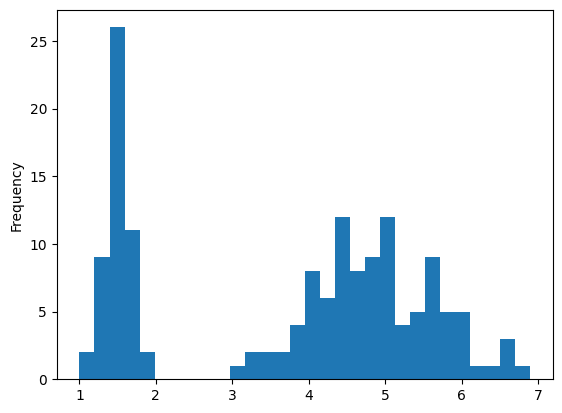

In [6]:
df["petal_length"].plot.hist(bins=30)

What is the smallest and largest value for petal length?

In [10]:
s = df["petal_length"].min()
l = df["petal_length"].max()
print(f"Min: {s}, max: {l}")

Min: 1.0, max: 6.9


Calculate the variance and standard deviation for petal length

In [12]:
import numpy as np

sdev = round(np.std(df["petal_length"], ddof=1), 2)
var = round(np.var(df["petal_length"], ddof=1), 2)
print(f"Variance: {var}, standard deviation: {sdev}")

Variance: 3.11, standard deviation: 1.76


Calculate the basic descriptive statistics for all columns of the iris data set with a single command.

In [13]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


What is the overall average for sepal length?

In [15]:
round(df["sepal_length"].mean(), 2)

np.float64(5.84)

Use the DataFrame grouping function to determine the count by species.

In [20]:
df.groupby("species").size()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

Use the DataFrame grouping function to determine the average length and width of sepals and pedals by species.

In [21]:
df.groupby("species").mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


Add the sum of the sepal width and length as a new column to your DataFrame.

In [22]:
df["sepal_total"] = df["sepal_length"] + df["sepal_width"]

Visualize petal length with a histogram

<Axes: ylabel='Frequency'>

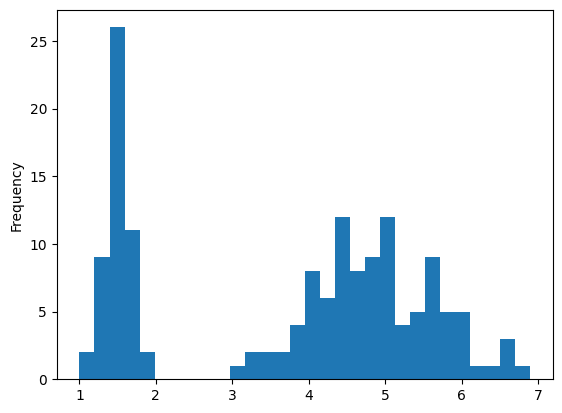

In [23]:
df["petal_length"].plot.hist(bins=30)

Describe the distribution

In [ ]:
# bimodal

Which is more informative: the summary statistics or visualizations?

In [ ]:
# Viz, as the present summary statistics don't hint at the bimodality

Visualize petal length and width with a "scatter_matrix"

<Axes: xlabel='petal_length', ylabel='petal_width'>

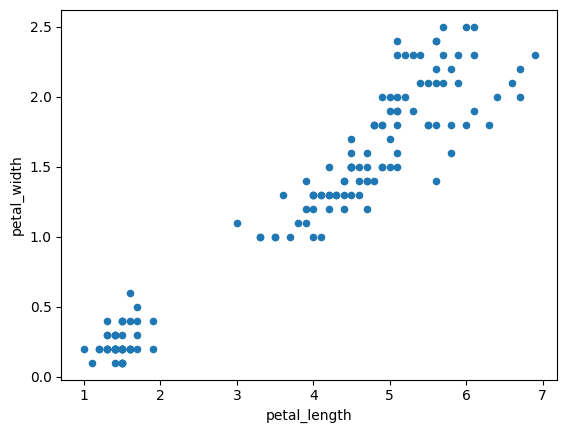

In [24]:
df.plot.scatter(x="petal_length", y="petal_width")

Create a new column with a rough estimate of petal area by multiplying petal length and width together.

In [25]:
df["petal_area"] = df["petal_length"] * df["petal_width"]

Create a new DataFrame with petal areas greater than $1cm^2$.

In [27]:
df3 = df[df["petal_area"] > 1]
df3.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_total,petal_area
50,7.0,3.2,4.7,1.4,Iris-versicolor,10.2,6.58
51,6.4,3.2,4.5,1.5,Iris-versicolor,9.6,6.75
52,6.9,3.1,4.9,1.5,Iris-versicolor,10.0,7.35
53,5.5,2.3,4.0,1.3,Iris-versicolor,7.8,5.20
54,6.5,2.8,4.6,1.5,Iris-versicolor,9.3,6.90


Create 3 new DataFrames, one for each species. Use the entire dataset.

In [ ]:


# dfs = {key: grp.copy() for key, grp in df.groupby("group_col")} # Alternative: groupby as iterator